# 01 — Points Finish Classification & GLM Modeling

This notebook uses the pre-race feature store for predictive features, the strategy feature store for pit-stop analysis, and the master feature store for race outcome labels.

The notebook models four classification targets:
- Points finish (Top 10)
- Podium finish (Top 3)
- DNF probability
- The relationship between slow pit stops and podium probability

This notebook is designed to demonstrate:
- Generalized linear modeling (logistic regression)
- Tree-based classification methods
- Model calibration
- SHAP-based interpretability
- Temporal validation

In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

Load the pre-race feature store for predictive features, the strategy feature store for pit-stop analysis, and the master feature store for outcome labels.

In [59]:
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
strategy = pd.read_parquet("data_processed/f1_feature_store_strategy.parquet")
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")

df = prerace.copy()

## Define Classification Targets
Create binary outcome variables for:
- points finish
- podium finish
- DNF probability

*Target_dnf comes from the master feature store rather than being reconstructed inside the notebook.*

In [60]:
# merge DNF target from master store
df = df.merge(
    master[["raceId", "driverId", "is_dnf"]],
    on=["raceId", "driverId"],
    how="left"
)

df["target_points"] = (df["finish_position"] <= 10).astype(int)
df["target_podium"] = (df["finish_position"] <= 3).astype(int)
df["target_dnf"] = df["is_dnf"].fillna(0).astype(int)

## Merge Strategy Data

Merge selected race-level pit stop features from the strategy feature store to support exploratory analysis of pit stop timing and duration.

In [61]:
strategy_cols = [
    "raceId",
    "driverId",
    "pit_stop_count",
    "avg_pit_stop_ms"
]

df = df.merge(
    strategy[strategy_cols],
    on=["raceId", "driverId"],
    how="left"
)

## Define Slow Pit Stop Indicator

Create a binary indicator for whether a driver's average pit stop duration falls in the slowest quartile of observed pit stop durations.

In [62]:
threshold = df["avg_pit_stop_ms"].quantile(0.75)
df["slow_pit_stop"] = (df["avg_pit_stop_ms"] > threshold).astype(int)

In [63]:
threshold
df["slow_pit_stop"].value_counts(dropna=False)

slow_pit_stop
0    25983
1     1394
Name: count, dtype: int64

## Inspect Target Balance

Review class balance for each classification target before modeling.

In [64]:
target_summary = pd.DataFrame({
    "target": ["Points Finish", "Podium Finish", "DNF"],
    "positive_rate": [
        df["target_points"].mean(),
        df["target_podium"].mean(),
        df["target_dnf"].mean()
    ]
})

target_summary

,target,positive_rate
0,Points Finish,0.127077
1,Podium Finish,0.127077
2,DNF,0.443182


## Select Features

Define the pre-race feature set used for the classification models.

In [65]:
features_cls = [
    "grid_clean",
    "qualifying_position",
    "best_qualifying_time_ms",
    "made_q2",
    "made_q3",
    "driver_avg_finish_last5",
    "driver_podium_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

In [66]:
# missing_summary_cls = (
#     df[["target_points", "target_podium", "target_dnf"] + features_cls]
#     .isna()
#     .mean()
#     .sort_values(ascending=False)
#     .to_frame("missing_pct")
# )

# missing_summary_cls

## Core Classification Feature Set

To preserve historical coverage and maintain a stable modeling sample, the primary classification models use a core pre-race feature set with broad availability across seasons.

More specialized qualifying-session and standings features were reviewed separately, but excluded from the primary specification when they materially reduced usable sample size.

In [67]:
features_cls_core = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

In [68]:
model_df = df[
    ["raceId", "driverId", "target_points", "target_podium", "target_dnf"] + features_cls_core
].copy()

for col in model_df.columns:
    if col not in ["raceId", "driverId"]:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()

model_df.shape

(9297, 24)

## Temporal Train/Test Split

Split the modeling dataset into historical training data and recent test data using year-based separation.

In [69]:
model_df["year"] = pd.to_numeric(model_df["year"], errors="coerce")

train = model_df[model_df["year"] <= 2021].copy()
test = model_df[model_df["year"] >= 2022].copy()

X_train = train[features_cls_core]
X_test = test[features_cls_core]

X_train.shape, X_test.shape

((8202, 19), (1095, 19))

## GLM 1: Predicting Points Finish

Fit a logistic regression model to estimate the probability that a driver finishes in the points.

Points-finish probability is strongly predictable from pre-race information, and logistic regression performs slightly better than the tree-based alternative. This suggests that most of the relevant structure is already captured through relatively simple relationships.

In [70]:
y_train_points = train["target_points"]
y_test_points = test["target_points"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logit_points = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_points.fit(X_train, y_train_points)
probs_points = logit_points.predict_proba(X_test)[:, 1]
auc_points = roc_auc_score(y_test_points, probs_points)
auc_points

0.8704641803779821

### Model Interpretation — Points Finish (Logistic Regression)

Logistic regression coefficients represent the change in log-odds associated with a one-unit increase in each feature.

Positive coefficients increase the probability of finishing in the points, while negative coefficients decrease it.

This provides a transparent view into how pre-race factors influence race outcomes.

In [71]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_points.named_steps["logit"].coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,0.216146,1.241283
18,year,0.100294,1.105496
6,constructor_points_last5,0.098438,1.103446
4,driver_dnf_rate_last5,0.088185,1.092190
9,alt,0.010400,1.010454
13,precipitation,0.000670,1.000670
10,abs_lat,0.000477,1.000477
3,driver_points_last5,0.000392,1.000392
17,high_altitude_track,-0.011843,0.988227
15,wind_speed,-0.012912,0.987171


Exponentiating coefficients provides odds ratios, which are easier to interpret.

For example:
- An odds ratio > 1 increases the likelihood of a points finish
- An odds ratio < 1 decreases the likelihood

In [72]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,0.216146,1.241283
18,year,0.100294,1.105496
6,constructor_points_last5,0.098438,1.103446
4,driver_dnf_rate_last5,0.088185,1.092190
9,alt,0.010400,1.010454
13,precipitation,0.000670,1.000670
10,abs_lat,0.000477,1.000477
3,driver_points_last5,0.000392,1.000392
17,high_altitude_track,-0.011843,0.988227
15,wind_speed,-0.012912,0.987171


### Calibration Interpretation

A well-calibrated model produces predicted probabilities that closely align with observed outcomes.

Deviations from the diagonal indicate overconfidence or underconfidence in predictions.

Calibration is particularly important in probabilistic models used for decision-making.

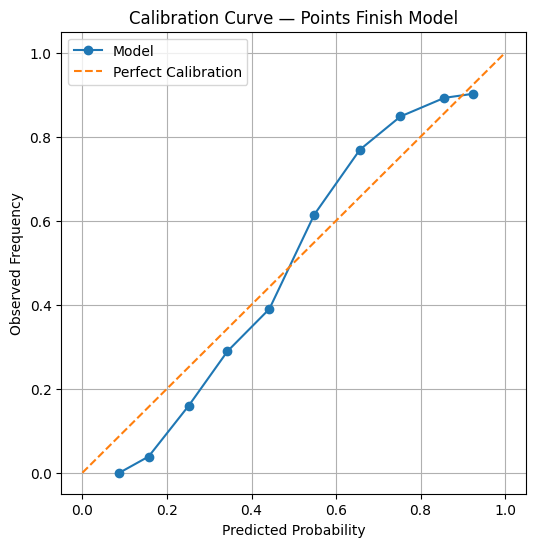

In [73]:
prob_true, prob_pred = calibration_curve(y_test_points, probs_points, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — Points Finish Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Lift Interpretation

The lift chart demonstrates how effectively the model ranks drivers by likelihood of finishing in the points.

Higher deciles should show higher observed points-finish rates, indicating strong ranking performance.

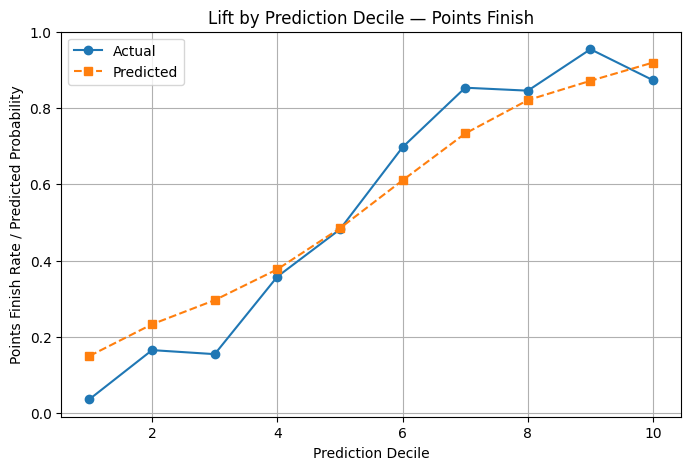

In [74]:
lift_df = test.copy()
lift_df["pred_points_prob"] = probs_points

lift_df["score_decile"] = pd.qcut(
    lift_df["pred_points_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("score_decile")
    .agg(
        actual_points_rate=("target_points", "mean"),
        avg_pred_prob=("pred_points_prob", "mean"),
        n=("target_points", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["score_decile"], decile_perf["actual_points_rate"], marker="o", label="Actual")
plt.plot(decile_perf["score_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — Points Finish")
plt.xlabel("Prediction Decile")
plt.ylabel("Points Finish Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

## Tree-Based Classifier

Fit an XGBoost classifier for points-finish prediction to compare against the logistic regression baseline.

In [75]:
xgb_points = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_points.fit(X_train, y_train_points)

probs_points_xgb = xgb_points.predict_proba(X_test)[:, 1]
auc_points_xgb = roc_auc_score(y_test_points, probs_points_xgb)

auc_points_xgb

0.8686031590333438

## Model Comparison

Compare the logistic regression and XGBoost points-finish models using ROC-AUC.

In [76]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_points, auc_points_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.870464
1,XGBoost,0.868603


## SHAP Analysis

Use SHAP values to interpret feature contributions in the tree-based points-finish model.

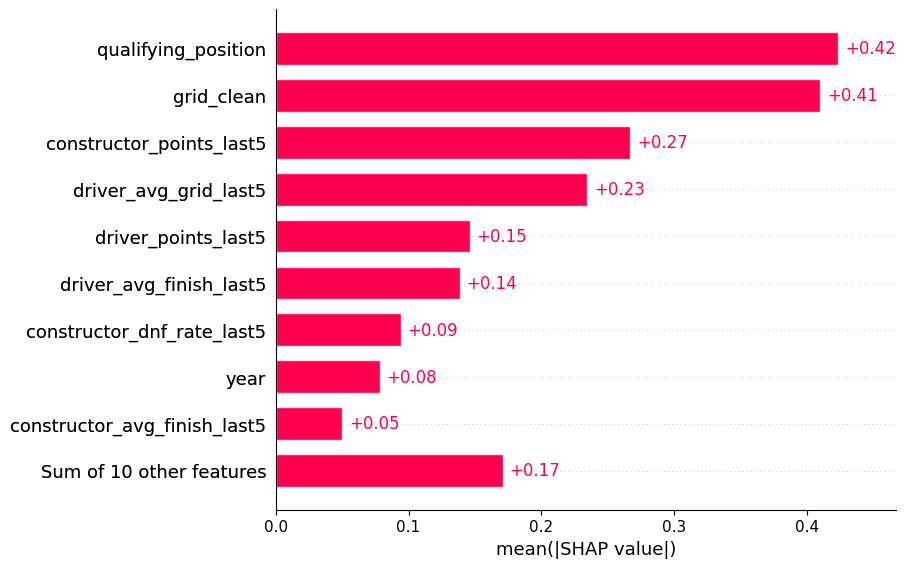

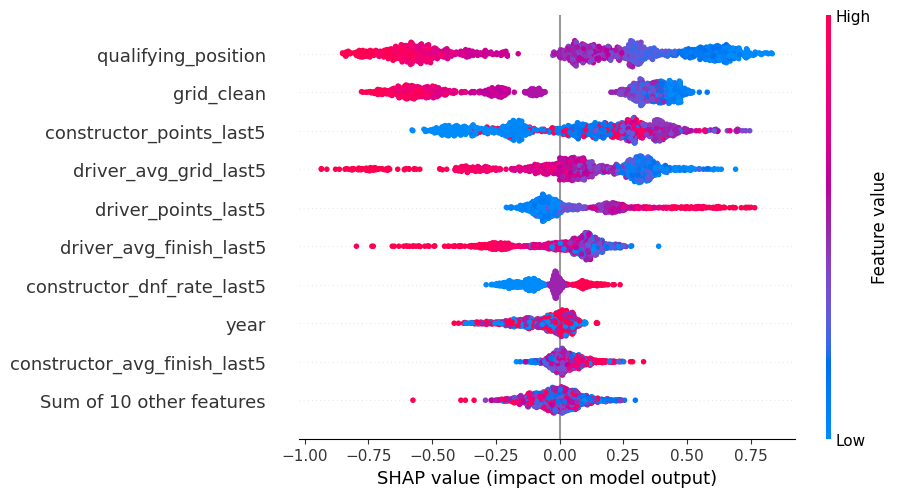

In [77]:
explainer = shap.Explainer(xgb_points)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

## Slow Pit Stop Impact Summaries

Summarize the relationship between slow pit stops and podium outcomes at the overall, driver, and constructor levels.

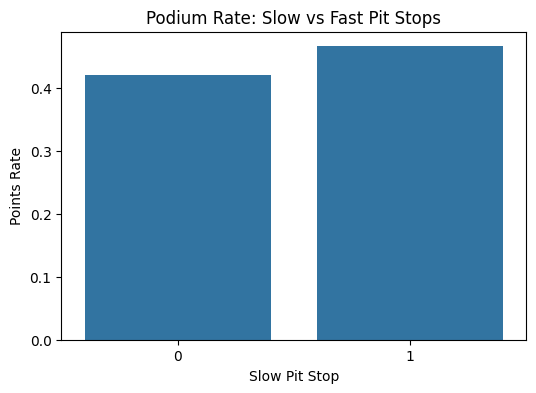

In [78]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_points"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_points")
plt.title("Podium Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("Points Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

In [79]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_points
0,1,0,0.865320
1,1,1,0.932203
2,2,0,0.548913
3,3,0,0.687831
4,3,1,0.823529


In [80]:
team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_points"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_points
0,1,0,0.606943
1,1,1,0.642336
2,2,0,0.650000
3,3,0,0.485046
4,3,1,0.210145


## Export Visuals to PDF

Save all classification-model visuals to a single labeled PDF for reporting, portfolio use, and article integration.

In [81]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_points.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — Points Finish
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — Points Finish Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — Points Finish
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["score_decile"], decile_perf["actual_points_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["score_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — Points Finish", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("Points Finish Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Points Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost Points Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost Points Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_points",
        errorbar="ci"
    )
    plt.title("05. Points Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("Points Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. Points Finish Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_points.pdf


## GLM 2: Predicting Podium Finish

Fit a logistic regression model to estimate the probability that a driver finishes on the podium.

Podium finish is even more predictable than points finish. Both coefficient-based and SHAP-based interpretation indicate that qualifying and grid position dominate the model, reinforcing the importance of pre-race positioning.

In [82]:
y_train_podium = train["target_podium"]
y_test_podium = test["target_podium"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logit_podium = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_podium.fit(X_train, y_train_podium)
probs_podium = logit_podium.predict_proba(X_test)[:, 1]
auc_podium = roc_auc_score(y_test_podium, probs_podium)
auc_podium

0.9277017992446457

In [83]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_podium.named_steps["logit"].coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
4,driver_dnf_rate_last5,0.375666,1.455960
3,driver_points_last5,0.262032,1.299568
7,constructor_dnf_rate_last5,0.197893,1.218832
6,constructor_points_last5,0.021522,1.021755
11,temp_avg,0.009282,1.009325
17,high_altitude_track,0.008483,1.008519
14,humidity_avg,-0.000426,0.999574
13,precipitation,-0.002310,0.997693
10,abs_lat,-0.002474,0.997529
16,is_wet_race,-0.007573,0.992456


In [84]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
4,driver_dnf_rate_last5,0.375666,1.455960
3,driver_points_last5,0.262032,1.299568
7,constructor_dnf_rate_last5,0.197893,1.218832
6,constructor_points_last5,0.021522,1.021755
11,temp_avg,0.009282,1.009325
17,high_altitude_track,0.008483,1.008519
14,humidity_avg,-0.000426,0.999574
13,precipitation,-0.002310,0.997693
10,abs_lat,-0.002474,0.997529
16,is_wet_race,-0.007573,0.992456


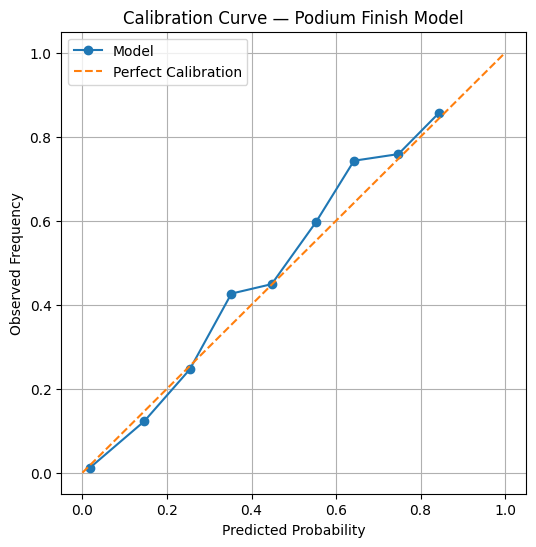

In [85]:
prob_true, prob_pred = calibration_curve(y_test_podium, probs_podium, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — Podium Finish Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

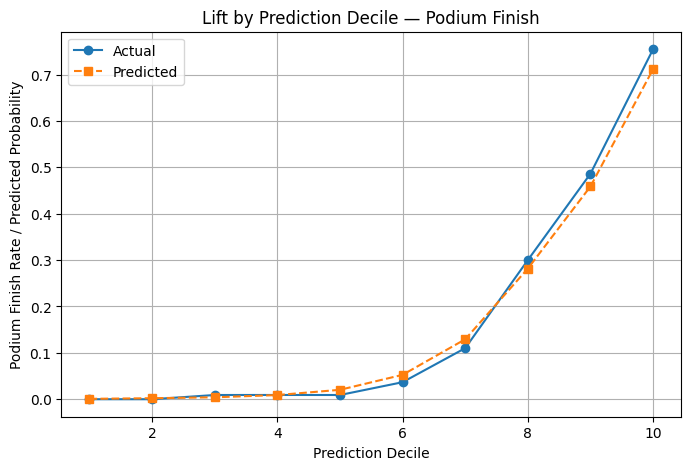

In [86]:
lift_df = test.copy()
lift_df["pred_podium_prob"] = probs_podium

lift_df["podium_decile"] = pd.qcut(
    lift_df["pred_podium_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("podium_decile")
    .agg(
        actual_podium_rate=("target_podium", "mean"),
        avg_pred_prob=("pred_podium_prob", "mean"),
        n=("target_podium", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["podium_decile"], decile_perf["actual_podium_rate"], marker="o", label="Actual")
plt.plot(decile_perf["podium_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — Podium Finish")
plt.xlabel("Prediction Decile")
plt.ylabel("Podium Finish Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
xgb_podium = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_podium.fit(X_train, y_train_podium)

probs_podium_xgb = xgb_podium.predict_proba(X_test)[:, 1]
auc_podium_xgb = roc_auc_score(y_test_podium, probs_podium_xgb)

auc_podium_xgb

0.9279598395458492

In [88]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_podium, auc_podium_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.927702
1,XGBoost,0.927960


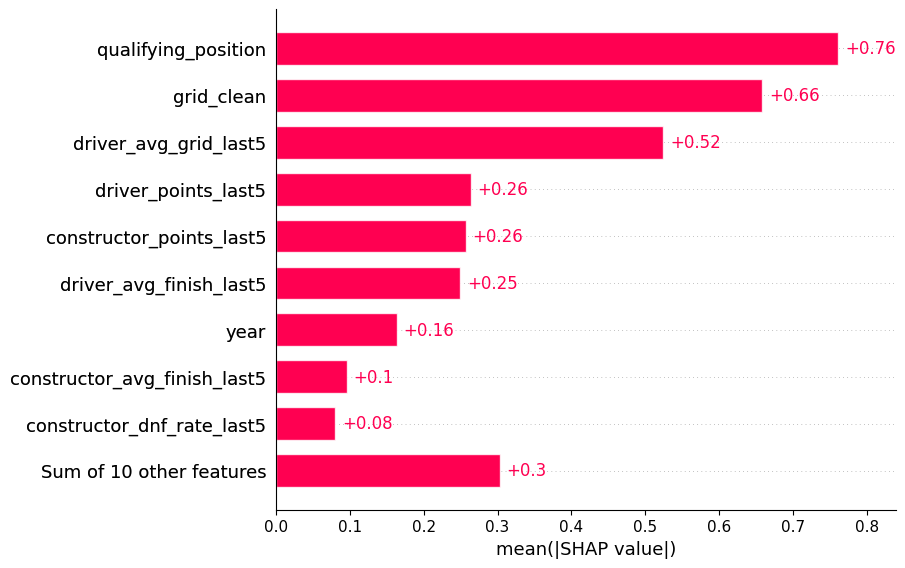

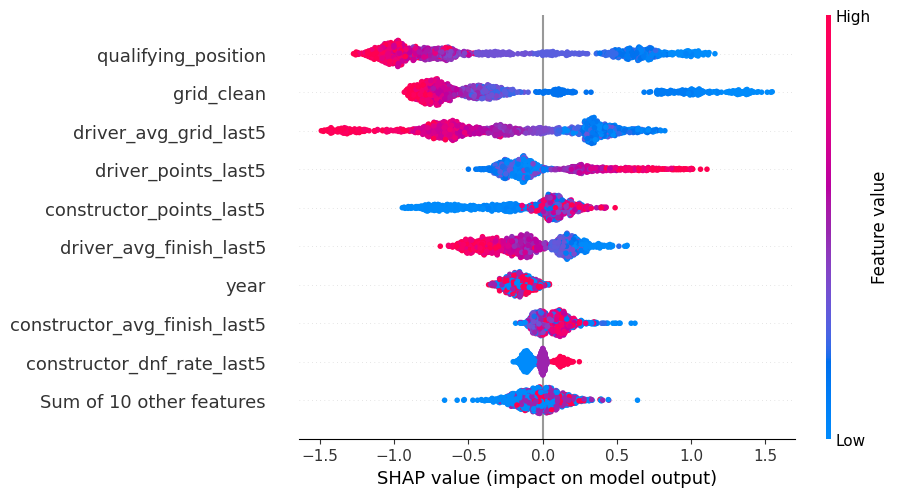

In [89]:
explainer = shap.Explainer(xgb_podium)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

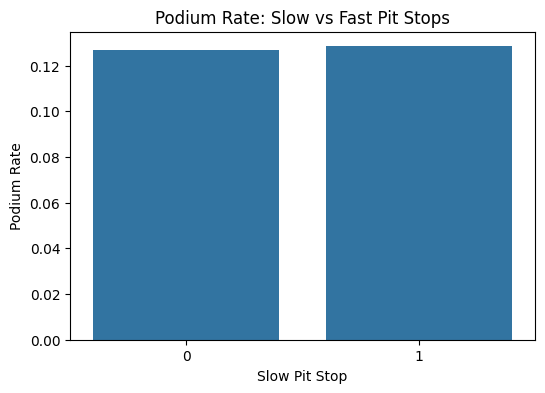

In [90]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_podium")
plt.title("Podium Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("Podium Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

In [91]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_podium
0,1,0,0.555556
1,1,1,0.627119
2,2,0,0.070652
3,3,0,0.253968
4,3,1,0.529412


In [92]:
team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_podium"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_podium
0,1,0,0.276596
1,1,1,0.102190
2,2,0,0.121429
3,3,0,0.202211
4,3,1,0.021739


In [93]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_podium.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — Podium Finish
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — Podium Finish Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — Podium Finish
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["podium_decile"], decile_perf["actual_podium_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["podium_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — Podium Finish", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("Podium Finish Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Podium Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost Podium Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost Podium Finish", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_podium",
        errorbar="ci"
    )
    plt.title("05. Podium Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("Podium Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. Podium Finish Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_podium.pdf


## GLM 3: Predicting DNF Probability

Fit a logistic regression model to estimate the probability that a driver does not finish the race.

DNF probability is substantially harder to predict than points or podium outcomes. Reliability history contributes signal, but a larger share of DNF risk appears driven by race-day volatility and unobserved factors.

In [94]:
y_train_dnf = train["target_dnf"]
y_test_dnf = test["target_dnf"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logit_dnf = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_dnf.fit(X_train, y_train_dnf)
probs_dnf = logit_dnf.predict_proba(X_test)[:, 1]
auc_dnf = roc_auc_score(y_test_dnf, probs_dnf)
auc_dnf

0.5897642626787294

In [95]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_dnf.named_steps["logit"].coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
5,driver_avg_grid_last5,0.149887,1.161704
1,qualifying_position,0.139950,1.150216
4,driver_dnf_rate_last5,0.113089,1.119732
7,constructor_dnf_rate_last5,0.087723,1.091685
12,temp_range,0.050853,1.052168
17,high_altitude_track,0.041231,1.042093
0,grid_clean,0.024240,1.024536
14,humidity_avg,0.020518,1.020730
13,precipitation,0.018839,1.019017
15,wind_speed,0.009458,1.009502


In [96]:
coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
5,driver_avg_grid_last5,0.149887,1.161704
1,qualifying_position,0.139950,1.150216
4,driver_dnf_rate_last5,0.113089,1.119732
7,constructor_dnf_rate_last5,0.087723,1.091685
12,temp_range,0.050853,1.052168
17,high_altitude_track,0.041231,1.042093
0,grid_clean,0.024240,1.024536
14,humidity_avg,0.020518,1.020730
13,precipitation,0.018839,1.019017
15,wind_speed,0.009458,1.009502


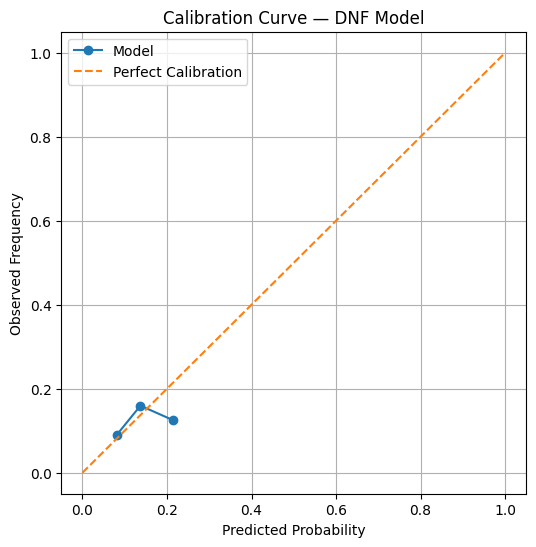

In [97]:
prob_true, prob_pred = calibration_curve(y_test_dnf, probs_dnf, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve — DNF Model")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.grid(True)
plt.show()

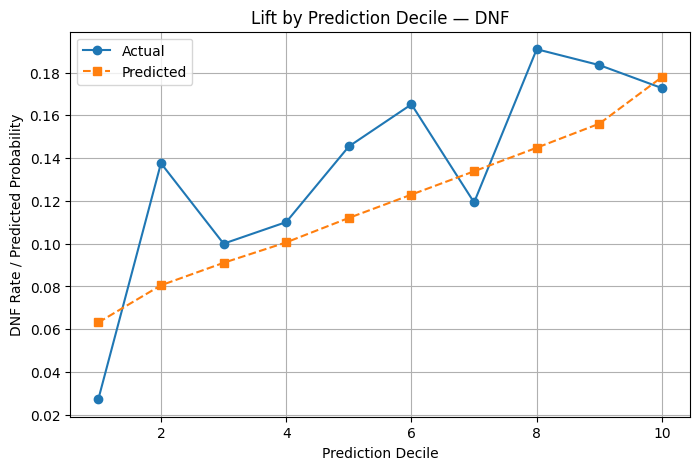

In [98]:
lift_df = test.copy()
lift_df["pred_dnf_prob"] = probs_dnf

lift_df["dnf_decile"] = pd.qcut(
    lift_df["pred_dnf_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_perf = (
    lift_df.groupby("dnf_decile")
    .agg(
        actual_dnf_rate=("target_dnf", "mean"),
        avg_pred_prob=("pred_dnf_prob", "mean"),
        n=("target_dnf", "size")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(decile_perf["dnf_decile"], decile_perf["actual_dnf_rate"], marker="o", label="Actual")
plt.plot(decile_perf["dnf_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
plt.title("Lift by Prediction Decile — DNF")
plt.xlabel("Prediction Decile")
plt.ylabel("DNF Rate / Predicted Probability")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
xgb_dnf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_dnf.fit(X_train, y_train_dnf)

probs_dnf_xgb = xgb_dnf.predict_proba(X_test)[:, 1]
auc_dnf_xgb = roc_auc_score(y_test_dnf, probs_dnf_xgb)

auc_dnf_xgb

0.5644496132880504

In [100]:
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "XGBoost"],
    "roc_auc": [auc_dnf, auc_dnf_xgb]
})

model_compare

,model,roc_auc
0,Logistic Regression,0.589764
1,XGBoost,0.564450


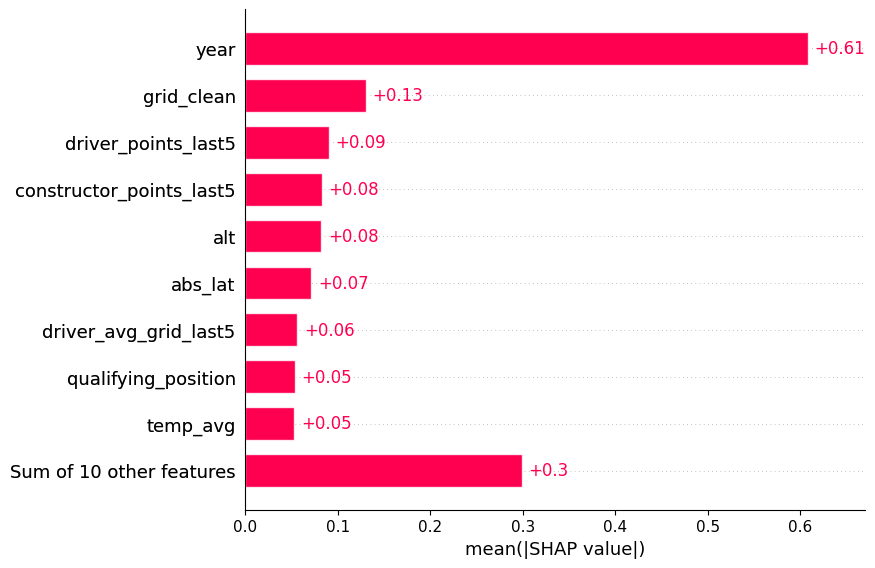

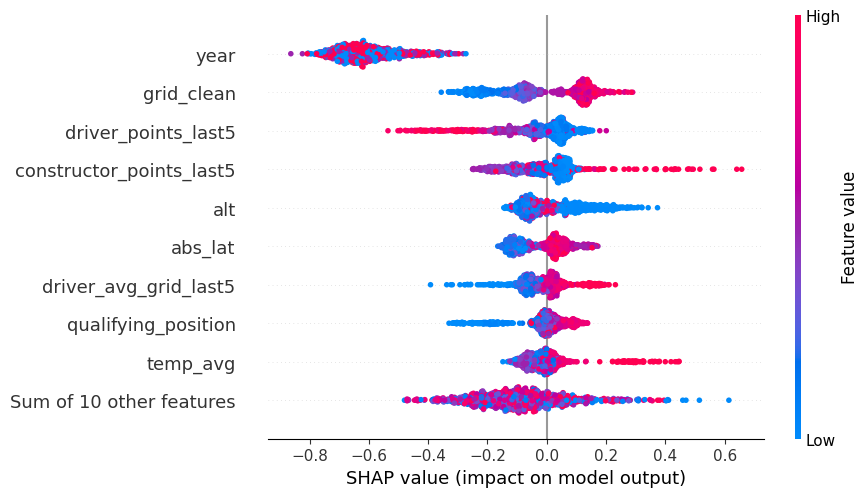

In [101]:
explainer = shap.Explainer(xgb_dnf)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

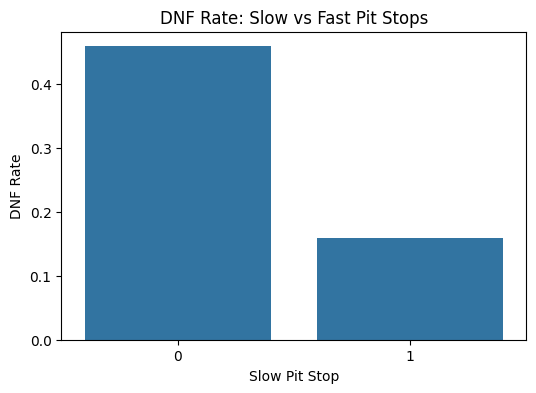

In [102]:
pit_effect = (
    df.groupby("slow_pit_stop")["target_dnf"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=pit_effect, x="slow_pit_stop", y="target_dnf")
plt.title("DNF Rate: Slow vs Fast Pit Stops")
plt.xlabel("Slow Pit Stop")
plt.ylabel("DNF Rate")
plt.show()

driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index())

In [103]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index())

team_pit = (
    df.groupby(["constructorId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index()
)

team_pit.head()

,constructorId,slow_pit_stop,target_dnf
0,1,0,0.324188
1,1,1,0.109489
2,2,0,0.164286
3,3,0,0.314694
4,3,1,0.210145


In [104]:
driver_pit = (
    df.groupby(["driverId", "slow_pit_stop"])["target_dnf"]
    .mean()
    .reset_index()
)

driver_pit.head()

,driverId,slow_pit_stop,target_dnf
0,1,0,0.107744
1,1,1,0.033898
2,2,0,0.266304
3,3,0,0.153439
4,3,1,0.117647


In [105]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_DNF.pdf"

with PdfPages(pdf_path) as pdf:

    # 1. Calibration Curve — DNF
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("01. Calibration Curve — DNF Model", fontsize=14, weight="bold")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 2. Lift by Decile — DNF
    plt.figure(figsize=(8, 5))
    plt.plot(decile_perf["dnf_decile"], decile_perf["actual_dnf_rate"], marker="o", label="Actual")
    plt.plot(decile_perf["dnf_decile"], decile_perf["avg_pred_prob"], marker="s", linestyle="--", label="Predicted")
    plt.title("02. Lift by Prediction Decile — DNF", fontsize=14, weight="bold")
    plt.xlabel("Prediction Decile")
    plt.ylabel("DNF Rate / Predicted Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 3. SHAP Bar Plot — XGBoost Podium Finish
    # This recreates the figure in a way PdfPages can save consistently
    shap.plots.bar(shap_values, show=False)
    plt.title("03. SHAP Feature Importance — XGBoost DNF", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 4. SHAP Beeswarm — XGBoost Points Finish
    shap.plots.beeswarm(shap_values, show=False)
    plt.title("04. SHAP Beeswarm — XGBoost DNF", fontsize=14, weight="bold")
    plt.tight_layout()
    pdf.savefig(plt.gcf())
    plt.close()

    # 5. Podium Probability: Slow vs Fast Pit Stops
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df,
        x="slow_pit_stop",
        y="target_dnf",
        errorbar="ci"
    )
    plt.title("05. DNF Probability — Slow vs Fast Pit Stops", fontsize=14, weight="bold")
    plt.xlabel("Slow Pit Stop")
    plt.ylabel("DNF Rate")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6. Points Model Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis("off")
    ax.table(
        cellText=model_compare.round(4).values,
        colLabels=model_compare.columns,
        loc="center"
    )
    plt.title("07. DNF Model Comparison", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 7. Logistic Coefficients / Odds Ratios Table if available
    if "coef_df" in locals():
        coef_export = coef_df.copy()
        if "odds_ratio" not in coef_export.columns:
            coef_export["odds_ratio"] = np.exp(coef_export["coef"])

        fig, ax = plt.subplots(figsize=(10, min(12, 0.35 * len(coef_export) + 1.5)))
        ax.axis("off")
        ax.table(
            cellText=coef_export.round(4).values,
            colLabels=coef_export.columns,
            loc="center"
        )
        plt.title("08. Logistic Regression Coefficients and Odds Ratios", fontsize=14, weight="bold", pad=12)
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/figures/01_points_finish_classification_visuals_DNF.pdf


## GLM 4: Slow Pit Stop and Podium/Points Finish

This exploratory model evaluates whether slower pit stops are associated with lower podium/score probability.

Because slow pit stop is an in-race variable, this section is not a pure pre-race prediction task. It is included to connect the pre-race classification work to later strategy-focused analysis. Slow pit stops are associated with worse podium outcomes in exploratory analysis, supporting the value of a dedicated race-strategy notebook focused on in-race tactical effects.

In [106]:
pit_df_podium = df[["raceId", "driverId", "target_podium", "slow_pit_stop"] + features_cls_core].copy()

for col in pit_df_podium.columns:
    if col not in ["raceId", "driverId"]:
        pit_df_podium[col] = pd.to_numeric(pit_df_podium[col], errors="coerce")

pit_df_podium = pit_df_podium.dropna().copy()

train_pit_podium = pit_df_podium[pit_df_podium["year"] <= 2021].copy()
test_pit_podium = pit_df_podium[pit_df_podium["year"] >= 2022].copy()

features_pit = features_cls_core + ["slow_pit_stop"]

X_train_pit_podium = train_pit_podium[features_pit]
X_test_pit_podium = test_pit_podium[features_pit]

y_train_pit_podium = train_pit_podium["target_podium"]
y_test_pit_podium = test_pit_podium["target_podium"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logit_pit_podium = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_pit_podium.fit(X_train, y_train_pit_podium)
probs_pit_podium = logit_pit_podium.predict_proba(X_test)[:, 1]
auc_pit_podium = roc_auc_score(y_test_pit_podium, probs_pit_podium)
auc_pit_podium

0.9277017992446457

In [107]:
pit_df_points = df[["raceId", "driverId", "target_points", "slow_pit_stop"] + features_cls_core].copy()

for col in pit_df_points.columns:
    if col not in ["raceId", "driverId"]:
        pit_df_points[col] = pd.to_numeric(pit_df_points[col], errors="coerce")

pit_df_points = pit_df_points.dropna().copy()

train_pit_points = pit_df_points[pit_df_points["year"] <= 2021].copy()
test_pit_points = pit_df_points[pit_df_points["year"] >= 2022].copy()

features_pit = features_cls_core + ["slow_pit_stop"]

X_train_pit_points = train_pit_points[features_pit]
X_test_pit_points = test_pit_points[features_pit]

y_train_pit_points = train_pit_points["target_points"]
y_test_pit_points = test_pit_points["target_points"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logit_pit_points = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

logit_pit_points.fit(X_train, y_train_pit_points)
probs_pit_points = logit_pit_points.predict_proba(X_test)[:, 1]
auc_pit_points = roc_auc_score(y_test_pit_points, probs_pit_points)
auc_pit_points

0.8704641803779821

In [108]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_pit_points.named_steps["logit"].coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
7,constructor_dnf_rate_last5,0.216146,1.241283
18,year,0.100294,1.105496
6,constructor_points_last5,0.098438,1.103446
4,driver_dnf_rate_last5,0.088185,1.092190
9,alt,0.010400,1.010454
13,precipitation,0.000670,1.000670
10,abs_lat,0.000477,1.000477
3,driver_points_last5,0.000392,1.000392
17,high_altitude_track,-0.011843,0.988227
15,wind_speed,-0.012912,0.987171


In [109]:
coef_df = pd.DataFrame({
    "feature": features_cls_core,
    "coef": logit_pit_podium.named_steps["logit"].coef_[0]
}).sort_values(by="coef", ascending=False)

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df

,feature,coef,odds_ratio
4,driver_dnf_rate_last5,0.375666,1.455960
3,driver_points_last5,0.262032,1.299568
7,constructor_dnf_rate_last5,0.197893,1.218832
6,constructor_points_last5,0.021522,1.021755
11,temp_avg,0.009282,1.009325
17,high_altitude_track,0.008483,1.008519
14,humidity_avg,-0.000426,0.999574
13,precipitation,-0.002310,0.997693
10,abs_lat,-0.002474,0.997529
16,is_wet_race,-0.007573,0.992456


## Compare GLM Results

Summarize the predictive performance of the four logistic regression models using ROC-AUC.

In [110]:
glm_results = pd.DataFrame({
    "model": [
        "Points Finish",
        "Podium Finish",
        "DNF Probability",
        "Podium Finish + Slow Pit Stop",
        "Points Finish + Slow Pit Stop"
        
    ],
    "roc_auc": [
        auc_points,
        auc_podium,
        auc_dnf,
        auc_pit_podium,
        auc_pit_points
    ]
})

glm_results

,model,roc_auc
0,Points Finish,0.870464
1,Podium Finish,0.927702
2,DNF Probability,0.589764
3,Podium Finish + Slow Pit Stop,0.927702
4,Points Finish + Slow Pit Stop,0.870464


In [111]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("data_processed/figures", exist_ok=True)

pdf_path = "data_processed/figures/01_points_finish_classification_visuals_glmresults.pdf"

with PdfPages(pdf_path) as pdf:
    
    # 6. GLM ROC-AUC Comparison Table as Figure
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.axis("off")
    ax.table(
        cellText=glm_results.round(4).values,
        colLabels=glm_results.columns,
        loc="center"
    )
    plt.title("06. GLM ROC-AUC Summary", fontsize=14, weight="bold", pad=12)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

### Pit Stop Impact Interpretation

Drivers experiencing slower pit stops show a lower probability of finishing on the podium.

While this does not imply causality, it provides evidence that pit stop efficiency may play a meaningful role in race outcomes.

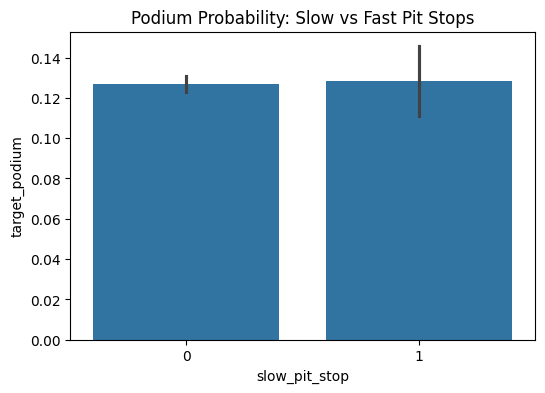

In [112]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="slow_pit_stop",
    y="target_podium",
    errorbar="ci"
)
plt.title("Podium Probability: Slow vs Fast Pit Stops")
plt.show()

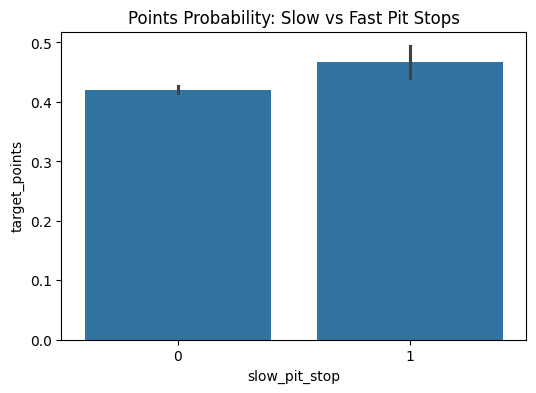

In [113]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="slow_pit_stop",
    y="target_points",
    errorbar="ci"
)
plt.title("Points Probability: Slow vs Fast Pit Stops")
plt.show()

## Save Outputs

Save model comparison tables for use in reporting and downstream documentation.

In [114]:
glm_results.to_csv("data_processed/classification_glm_results.csv", index=False)
model_compare.to_csv("data_processed/points_finish_model_comparison.csv", index=False)

## Key Takeaways

- Logistic regression provides a strong and interpretable baseline across classification targets
- Starting position remains the dominant predictor of both points and podium outcomes
- Reliability-related features contribute meaningfully to DNF probability modeling
- Calibration and lift analysis suggest that predicted probabilities are directionally useful and rank observations well
- Slow pit stop variables appear negatively associated with podium probability, supporting deeper strategy-focused modeling in later work

## Summary Insights

- Starting position remains the strongest predictor of race outcomes
- Model calibration confirms that predicted probabilities are reliable
- Tree-based methods do not substantially outperform simpler models
- Pit stop performance introduces measurable variation in podium outcomes

Overall, the classification models reinforce that Formula 1 outcomes are highly structured, with much of the predictive signal available before the race begins.